In [1]:
import allel
print("allel:",allel.__version__)
import numpy as np
print("numpy:",np.__version__)

import re
import sys

from tabulate import tabulate
import pandas as pd

allel: 1.3.5
numpy: 1.21.6


In [2]:
from plotnine import *

In [11]:
#vcf='phased_shapeit_1_200samples.vcf.gz'
vcffile='resources/Aaeg1200g/aegy.wgs.aaa.aaf.norep5-30x.ac10.thinrand01.phased.chr{}.vcf.gz'
#vcf='resources/Aaeg1200g/aegy.wgs.aaa.aaf.mapQ20.GoodSites.chr3.SNP.refseq.7e6.phased.vcf.gz'
#vcf='resources/Aaeg1200g/shapeit.kdr3.vcf.gz'
metafile='resources/meta_Aaeg1kg_spp.txt'

poplevel = 'country'
pop1='USA'

hapsfile = 'resources/aaeg_hap_loci.txt'

In [45]:
haps = pd.read_csv(hapsfile, sep='\t')
haps['pos'] = round(np.mean(haps[['start','end']],1))
haps['chr'] = haps['chrom']
haps = haps[haps['locusname'].isin(['kdr3','ace','rdl2'])]
haps

,chrom,start,end,locusname,geneid,regionstring,pos,chr
0,2,41628484,41861946,rdl2,AAEL008354,NC_035108.1:41628484-41861946,41745215.0,2
2,3,315926360,316405639,kdr3,AAEL023266,NC_035109.1:315926360-316405639,316166000.0,3
4,1,142163173,142283642,ace,AAEL021432,NC_035107.1:142163173-142283642,142223408.0,1


In [5]:
meta = np.genfromtxt(metafile,delimiter='\t',names=True,dtype=None,encoding='utf-8')

pops, popn = np.unique(meta['pop'][meta[poplevel]==pop1], return_counts=True)
pd.DataFrame({"pop":pops,
              "popn":popn})

,pop,popn
0,Clovis,16
1,Coachella,19
2,LasCruces,18
3,LosAngeles,20
4,MaricopaCounty,23
5,Miami,15
6,NewOrleans,15
7,Roswell,19


In [72]:
h12tab = pd.DataFrame(columns = ["pop","chr","pos","h1","h12","h123","h2_h1"])
posns = None
npos  = -1

blen=1000
bstep=250
for chrom in [1,2,3]:
    vcf = vcffile.format(chrom)
    #region='NC_035109.1:300000000-320000000'
    npos=-1
    for pop2 in pops:
        print('{} {}'.format(chrom,pop2),file=sys.stderr)
        pop1samps = meta['sample'][meta['pop']==pop2]
        callset1 = allel.read_vcf(vcf, 
     #                             region=region,
                                  samples=pop1samps, 
                                  fields=['calldata/GT','variants/POS'])

        if npos<0:
            posns = allel.moving_statistic(callset1['variants/POS'], np.average, blen, step=bstep)
            npos = posns.size
        gtpop1 = allel.GenotypeArray(callset1['calldata/GT'])
        hppop1 = gtpop1.to_haplotypes()

        #get h12 values in windows
        h1, h12, h123, h2_h1 = allel.moving_garud_h(hppop1, blen, start=0, stop=None, step=bstep)

        newdf = pd.DataFrame(data={"pop"  :[pop2]*npos,
                                   "chr"  :[chrom]*npos,
                                   "pos"  :posns,
                                   "h1"   :h1,
                                   "h12"  :h12,
                                   "h123" :h123,
                                   "h2_h1":h2_h1},
                     columns=["pop","chr","pos","h1","h12","h123","h2_h1"])
        h12tab = h12tab.append(newdf)


1 Clovis
1 Coachella
1 LasCruces
1 LosAngeles
1 MaricopaCounty
1 Miami
1 NewOrleans
1 Roswell
2 Clovis
2 Coachella
2 LasCruces
2 LosAngeles
2 MaricopaCounty
2 Miami
2 NewOrleans
2 Roswell
3 Clovis
3 Coachella
3 LasCruces
3 LosAngeles
3 MaricopaCounty
3 Miami
3 NewOrleans
3 Roswell


In [73]:
h12tab

,pop,chr,pos,h1,h12,h123,h2_h1
0,Clovis,1,1.226514e+05,0.031250,0.033203,0.037109,0.968750
1,Clovis,1,1.715550e+05,0.031250,0.033203,0.037109,0.968750
2,Clovis,1,2.137696e+05,0.031250,0.033203,0.037109,0.968750
3,Clovis,1,2.523682e+05,0.031250,0.033203,0.037109,0.968750
4,Clovis,1,2.860006e+05,0.031250,0.033203,0.037109,0.968750
...,...,...,...,...,...,...,...
9786,Roswell,3,4.093957e+08,0.026316,0.027701,0.030471,0.973684
9787,Roswell,3,4.094553e+08,0.026316,0.027701,0.030471,0.973684
9788,Roswell,3,4.095119e+08,0.026316,0.027701,0.030471,0.973684
9789,Roswell,3,4.095690e+08,0.026316,0.027701,0.030471,0.973684


In [74]:
h12tab.to_csv('h12_{}bp_all_chroms.txt'.format(blen), sep ='\t')

/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 500.0 x 200.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_1000bp_allchroms_thinrand.png


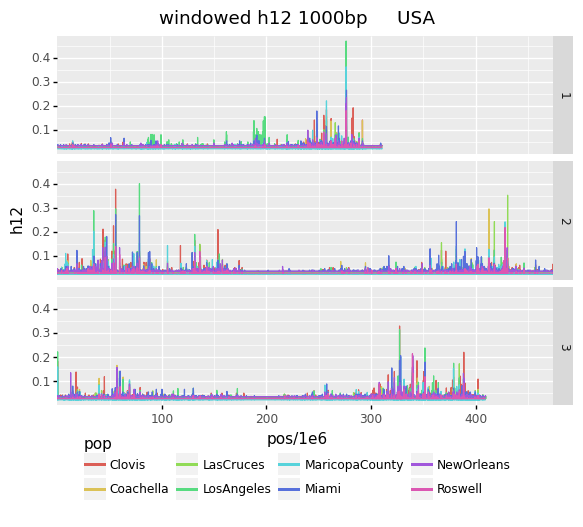

In [75]:
p = ggplot(h12tab,aes(x='pos/1e6',y="h12",color="pop")) + \
  geom_line() + \
  ggtitle("windowed h12 {win}bp     {p1}".format(win=blen,p1=pop1)) +\
  scale_x_continuous(expand=(0,0)) +\
  theme(legend_position='bottom') + facet_grid(("chr","."))
ggsave(plot=p, width=500,height=200,units='mm',filename='h12_{}bp_allchroms_thinrand.png'.format(blen), dpi=400)
print(p)


/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 500.0 x 200.0 mm image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: h12_1000bp_allchroms_thinrand_loci.png


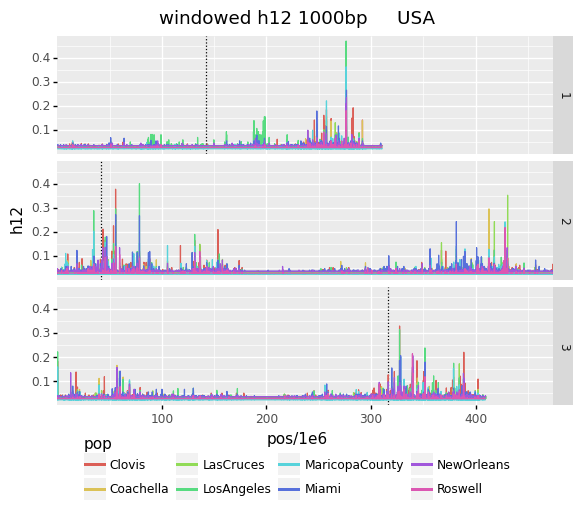

In [76]:
p = ggplot(h12tab,aes(x='pos/1e6',y="h12")) + \
  geom_vline(aes(xintercept='pos/1e6'),data=haps,linetype="dotted") +\
  geom_text(aes(x='pos/1e6',label='locusname'),data=haps,y=0.9,ha='left') +\
  geom_line(aes(x='pos/1e6',color="pop")) + \
  ggtitle("windowed h12 {win}bp     {p1}".format(win=blen,p1=pop1)) +\
  scale_x_continuous(expand=(0,0)) +\
  theme(legend_position='bottom') + facet_grid(("chr","."))
ggsave(plot=p, width=500,height=200,units='mm',filename='h12_{}bp_allchroms_thinrand_loci.png'.format(blen), dpi=400)
print(p)
